In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import gravity_toolkit
import netCDF4 as nc
import yaml
import pyshtools as sh
from gravity_toolkit.read_GRACE_harmonics import read_GRACE_harmonics

In [2]:
#using gravity_toolkit module

In [3]:
CSR_L2_input_2020 = read_GRACE_harmonics('GSM-2_2020001-2020031_GRFO_UTCSR_BA01_0603',60) #60 (from metadata)
CSR_L2_input_2025 = read_GRACE_harmonics('GSM-2_2025001-2025031_GRFO_UTCSR_BA01_0603',60)

In [4]:
coeffs_2020 = sh.SHCoeffs.from_array(np.array([CSR_L2_input_2020['clm'], CSR_L2_input_2020['slm']]), normalization='4pi', csphase=1) 
coeffs_2025 = sh.SHCoeffs.from_array(np.array([CSR_L2_input_2025['clm'], CSR_L2_input_2025['slm']]), normalization='4pi', csphase=1) 

In [5]:
var_clm_2020 = CSR_L2_input_2020['eclm']**2
var_slm_2020 = CSR_L2_input_2020['eslm']**2 #take variances

var_clm_2025 = CSR_L2_input_2025['eclm']**2
var_slm_2025 = CSR_L2_input_2025['eslm']**2

In [6]:
#Create error coefficients object using pyshtools
error_coeffs_2020 = np.zeros((2, 61, 61))
error_coeffs_2020[0, :, :] = var_clm_2020
error_coeffs_2020[1, :, :] = var_slm_2020
coeffs_obj_2020 = sh.SHCoeffs.from_array(error_coeffs_2020)

error_coeffs_2025 = np.zeros((2, 61, 61))
error_coeffs_2025[0, :, :] = var_clm_2025
error_coeffs_2025[1, :, :] = var_slm_2025
coeffs_obj_2025 = sh.SHCoeffs.from_array(error_coeffs_2025)

In [7]:
#Expanding the sum of variances gives the spatial variance at each point, for uncaliberated std dev plots (if wanted)
error_grid_2020 = coeffs_obj_2020.expand(grid='DH')
spatial_std_2020 = np.sqrt(np.abs(error_grid_2020).data)  #root of spatial variance = Std Dev

error_grid_2025 = coeffs_obj_2025.expand(grid='DH')
spatial_std_2025 = np.sqrt(np.abs(error_grid_2025).data)

In [8]:
grid_2020 = coeffs_2020.expand(grid='DH') #expand to a DH grid (Driscoll and Healy)
data_2020 = grid_2020.data  #2D array of values

grid_2025 = coeffs_2025.expand(grid='DH')
data_2025 = grid_2025.data
lats = grid_2025.lats()
lons = grid_2025.lons()

In [9]:
diff = data_2025 - data_2020 #to check mass loss

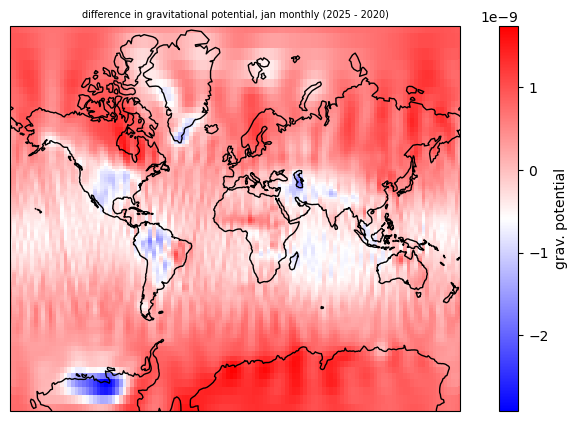

In [10]:
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.Mercator())

#global context
ax.coastlines()
ax.set_global()

#transform must be PlateCarree for lon/lat data
mesh = ax.pcolormesh(lons, lats, diff, transform=ccrs.PlateCarree(), cmap='bwr')

plt.colorbar(mesh, orientation='vertical', label='grav. potential')
plt.title('difference in gravitational potential, jan monthly (2025 - 2020)', fontsize = 7)
plt.show()